# Individuality across learning: three tests that separate the ways it can fail

`lda_sweep_timepoints` fits an LDA on proficient sessions and asks it to name each mouse
from its Early, Late or Pre-recording session. At 25 dimensions that gives Early 0.03
(chance 0.03), Late 0.07 (0.02) and Pre-recording 0.49 (0.03). A low score there can mean
any of:

1. **the whole cloud shifts**: rig, camera, task variant and stage move every mouse
   together, so absolute positions learned at proficiency are wrong earlier, even if the
   mice keep their arrangement;
2. **top-1 among ~40 mice is harsh**: a mouse ranked 2nd of 40 scores zero;
3. **one session per mouse** at Early and Late, so each query is a single noisy session;
4. **the signature genuinely changes** with learning, which would be a finding;
5. **the axes are tuned to proficient differences**, which need not be the ones that
   separate mice early.

This notebook separates them:

| | question | removes |
|---|---|---|
| **A** | is there individuality *within* each stage? split each session into two halves and identify mice half against half | 1, 4, 5 |
| **B** | is a mouse recognisable *across* stages once each stage's shift is removed, scored by rank instead of top-1? | 1, 2, 5 |
| **C** | is the *arrangement* of mice preserved across stages (Mantel on mouse × mouse distances), with a noise ceiling built the same way for every stage? | 1, 2, 5, any rotation |

**One representation throughout: decorrelated syllable space.** Session-mean syllable
features (360), z-scored within stage, then decorrelated with a shrunk covariance estimated
without labels. In `lda_shrinkage_figures` this label-free space identified proficient mice
almost as well as the LDA (0.86 vs 0.87), and it has no proficient-tuned axes (failure 5).
Distances are Euclidean in that space.

**Same syllable model at every stage.** The training-stage files exist only as `paw_wheel`
segmentations, so the proficient file here is `paw_wheel_8_k_10_bin_syllables_28-08-2026`,
not the `8_k_10_bin_syllables_19-08-2026` that `lda_shrinkage` uses. The two code syllables
differently, so they cannot be mixed.

**Matched difficulty.** Stages have different numbers of mice (19–101), and top-1 accuracy
depends on that. Every top-1 here is therefore reported **among `N_MATCH` candidates**,
computed exactly (no subsampling noise) as the probability that the true mouse beats
`N_MATCH − 1` randomly drawn competitors. Alongside it is the **rank percentile** of the true
mouse among all candidates (1 = nearest, 0.5 = chance).

In [1]:
# ---- KNOBS ------------------------------------------------------------------------
QC_STRICTNESS = 'filtered_out'
MAX_SESSION_MISSING = 0.1      # same screen as lda_shrinkage, applied at every stage
SHRINKAGE = 0.5                # covariance shrinkage for the decorrelation (as lda_shrinkage)
N_SPLITS = 20                  # random half-splits / session draws per analysis
N_MATCH = 15                   # candidates for the matched top-1 (<= smallest cohort, 19)
N_PERM = 5000                  # Mantel permutations
SEED = 0

STAGE_FILES = {
    'Early':      'training/paw_wheel_session_1_8_k_10_bin_syllables_04-09-2026',
    'Late':       'training/paw_wheel_last_training_8_k_10_bin_syllables_04-09-2026',
    'Pre-rec':    'training/paw_wheel_biased_8_k_10_bin_syllables_04-09-2026',
    'Proficient': 'paw_wheel_8_k_10_bin_syllables_28-08-2026',
}
STAGES = list(STAGE_FILES)
EPOCHS = ['Pre-quiescence', 'Quiescence', 'Choice', 'ITI']
N_PAW_STATES = 8

In [2]:
import sys
import pathlib
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.special import comb
from scipy.stats import spearmanr


def _find_paper_style():
    here = pathlib.Path.cwd().resolve()
    for cand in [here, *here.parents]:
        if (cand / 'paper_style.py').exists():
            return cand
        if (cand / 'paper-individuality' / 'paper_style.py').exists():
            return cand / 'paper-individuality'
    raise FileNotFoundError(f'paper_style.py not found above {here}')


_root = _find_paper_style()
for _p in (_root, _root / 'learning_individuality', _root / '4_mice'):
    if str(_p) not in sys.path:
        sys.path.insert(0, str(_p))
import importlib
import paper_style as ps
importlib.reload(ps)
ps.use('paper')
import session_filters
from session_filters import exclusions_by_timepoint
import functions

DATA = _root / 'data'
EXCL = exclusions_by_timepoint(QC_STRICTNESS)
print('QC exclusions:', {k: len(v) for k, v in EXCL.items()})
STAGE_COLOR = {s: ps.TIMEPOINT[s] for s in STAGES}
STAGE_LABEL = {s: ps.TIMEPOINT_LABEL[s] for s in STAGES}
rng_master = np.random.default_rng(SEED)

paper_style: paper mode, spines=lb, font 8 pt, panels 3.4x2.4 in, save 400 dpi


QC exclusions: {'Early': 15, 'Late': 9, 'Pre-rec': 76, 'Proficient': 12, 'Habituation': 0}


## Trial-level features per stage

One row per trial: the 360 one-hot syllable columns (7 paw + whisk + lick per time bin, paw
state 1 dropped as the reference), exactly `lda_shrinkage`'s layout. Trials are kept, not
averaged, because Test A splits each session's trials into halves.

In [3]:
def binarize(use_sequences, n_paw_states=N_PAW_STATES):
    """lda_shrinkage's binarize: one block of (paw states + whisk + lick) per time bin,
    paw state 1 dropped as the reference; NaN bins stay NaN."""
    n_trials, timesteps = use_sequences.shape
    per_step = n_paw_states + 2
    out = np.zeros((n_trials, timesteps * per_step), dtype=np.float32)
    for t in range(timesteps):
        vals = use_sequences[:, t]
        valid = ~np.isnan(vals)
        labels = vals[valid].astype(int)
        start = t * per_step
        if len(labels):
            rows = np.arange(n_trials)[valid]
            out[rows, start + labels % n_paw_states] = 1
            out[valid, start + n_paw_states] = (labels // n_paw_states) % 2
            out[valid, start + n_paw_states + 1] = labels // (n_paw_states * 2)
        if (~valid).any():
            out[~valid, start:start + per_step] = np.nan
    return np.delete(out, [t * per_step + 1 for t in range(timesteps)], axis=1)


def load_stage(name):
    seq = pd.read_parquet(DATA / STAGE_FILES[name])
    seq['session'] = seq['sample'].str[:36]
    n0 = seq['session'].nunique()
    drop = set(EXCL[name]) | (set(EXCL['Proficient']) if name == 'Proficient' else set())
    seq = seq.loc[~seq['session'].isin(drop)]
    nan_frac = np.isnan(np.stack(seq['binned_sequence'].to_numpy())).mean(axis=1)
    by_sess = pd.Series(nan_frac, index=seq['session'].to_numpy()).groupby(level=0).mean()
    seq = seq.loc[~seq['session'].isin(by_sess[by_sess > MAX_SESSION_MISSING].index)]
    trials = (seq.pivot(index=['mouse_name', 'session', 'sample', 'trial_type'],
                        columns='broader_label', values='binned_sequence')
              .reset_index().dropna().sort_values(['session', 'sample']))
    F = binarize(np.vstack(trials[EPOCHS].apply(lambda r: np.hstack(r), axis=1)))
    st = dict(F=F, mouse=trials['mouse_name'].to_numpy(), session=trials['session'].to_numpy())
    st['sess_codes'], st['sessions'] = pd.factorize(st['session'])
    st['sess_mouse'] = pd.Series(st['mouse'], index=st['session']).groupby(level=0).first() \
                         .reindex(st['sessions']).to_numpy()
    print(f'{name:11s} {n0:4d} sessions in file -> {len(st["sessions"]):4d} kept, '
          f'{len(np.unique(st["mouse"])):3d} mice, {len(F):6d} trials')
    return st


def session_means(F, codes, n_sess, mask=None):
    """Per-session nanmean of the trial rows (optionally only rows in `mask`)."""
    if mask is not None:
        F, codes = F[mask], codes[mask]
    ok = ~np.isnan(F)
    S = np.zeros((n_sess, F.shape[1]))
    N = np.zeros((n_sess, F.shape[1]))
    np.add.at(S, codes, np.where(ok, F, 0))
    np.add.at(N, codes, ok)
    with np.errstate(invalid='ignore'):
        return S / N


DATA_BY_STAGE = {s: load_stage(s) for s in STAGES}
for s, st in DATA_BY_STAGE.items():
    st['full'] = session_means(st['F'], st['sess_codes'], len(st['sessions']))

# mouse -> lab, from the proficient sessions (each mouse is in one lab)
_p = DATA_BY_STAGE['Proficient']
_lab = functions.lab_labels(_p['sessions'], mouse_names=pd.Series(_p['sess_mouse'],
                                                                 index=_p['sessions']),
                            verbose=False)
LAB_OF_MOUSE = pd.Series(np.asarray(_lab), index=_p['sess_mouse']).groupby(level=0).first()
print(f'\nlabs known for {len(LAB_OF_MOUSE)} mice')

Early         47 sessions in file ->   35 kept,  35 mice,   7945 trials


Late          55 sessions in file ->   49 kept,  49 mice,  34658 trials


Pre-rec      116 sessions in file ->   93 kept,  37 mice,  71504 trials


Proficient   332 sessions in file ->  330 kept, 101 mice, 205269 trials



labs known for 101 mice


## Shared machinery

* `space(ref)` builds the decorrelated space from a reference set of session vectors,
  with no labels: z-score with the reference's mean and SD, then whiten with its shrunk
  covariance.
* `rank_scores(D, own)` turns a query × candidate distance matrix into the two scores: the
  exact matched top-1 among `N_MATCH` candidates, and the rank percentile.

In [4]:
def space(ref):
    """Label-free decorrelated space fit on `ref` (rows = session vectors)."""
    ref = np.asarray(ref, float)
    mu = np.nanmean(ref, axis=0)
    sd = np.nanstd(ref, axis=0)
    keep = sd > 1e-8
    Z = (ref[:, keep] - mu[keep]) / sd[keep]
    Z = np.where(np.isnan(Z), 0, Z)
    C = np.cov(Z.T)
    C = (1 - SHRINKAGE) * C + SHRINKAGE * np.trace(C) / len(C) * np.eye(len(C))
    w, V = np.linalg.eigh(C)
    W = V / np.sqrt(w)

    def f(A):
        A = (np.asarray(A, float)[:, keep] - mu[keep]) / sd[keep]
        return np.where(np.isnan(A), 0, A) @ W
    return f


def sqdist(Q, C):
    return ((Q[:, None, :] - C[None, :, :]) ** 2).sum(axis=2)


def rank_scores(D, own, n_match=N_MATCH):
    """D: queries x candidates distances; own[i] = column of query i's true mouse.
    Returns (matched top-1, rank percentile, full top-1), each averaged over queries.
    Matched top-1 is exact: with c competitors closer than the true mouse out of N-1,
    P(true mouse wins against n-1 random competitors) = C(N-1-c, n-1) / C(N-1, n-1)."""
    nq, N = D.shape
    d_own = D[np.arange(nq), own]
    closer = (D < d_own[:, None]).sum(axis=1)        # competitors closer than own
    n = min(n_match, N)
    top1_matched = comb(N - 1 - closer, n - 1) / comb(N - 1, n - 1)
    pct = 1 - closer / (N - 1)
    return float(top1_matched.mean()), float(pct.mean()), float((closer == 0).mean())


def one_session_per_mouse(st, rng, mice=None, exclude=None):
    """Index of one random session per mouse (optionally only `mice`, never `exclude`)."""
    out = {}
    for m in (np.unique(st['sess_mouse']) if mice is None else mice):
        idx = np.where(st['sess_mouse'] == m)[0]
        if exclude is not None:
            idx = idx[~np.isin(idx, exclude.get(m, []))]
        if len(idx):
            out[m] = rng.choice(idx)
    return out


def half_split(st, sess_idx, rng):
    """For the given sessions: (half-A means, half-B means), trials split at random."""
    rows = np.isin(st['sess_codes'], sess_idx)
    codes = st['sess_codes'][rows]
    F = st['F'][rows]
    r = rng.random(len(codes))
    # rank within session -> first half / second half of a random order
    order = pd.Series(r).groupby(codes).rank(method='first').to_numpy()
    size = pd.Series(codes).map(pd.Series(codes).value_counts()).to_numpy()
    in_a = order <= size / 2
    remap = {c: i for i, c in enumerate(sess_idx)}
    cc = np.array([remap[c] for c in codes])
    return (session_means(F, cc, len(sess_idx), in_a),
            session_means(F, cc, len(sess_idx), ~in_a))

## A. Is there individuality within each stage?

Per split: one random session per mouse; its trials split at random into two halves. The
query is a mouse's half B, and the candidates are every mouse's half A. The space is fit on
the half-A vectors without labels.

**Calibration.** Two halves of one session share that day's conditions (camera placement,
lighting, motivation), so split-half identification is **optimistic** as a measure of a
mouse's lasting signature. Where mice have ≥ 2 sessions (Pre-recording, Proficient), the
same test is also run **across sessions with the same amount of data**: half of session 1
against half of session 2. The gap between the two bars is how much the within-session
version overstates individuality. Early and Late have one session per mouse, so only the
optimistic version exists for them, and it should be read against that gap.

In [5]:
def within_stage(st, rng, cross_session=False):
    mice2 = [m for m in np.unique(st['sess_mouse'])
             if (st['sess_mouse'] == m).sum() >= (2 if cross_session else 1)]
    s1 = one_session_per_mouse(st, rng, mice2)
    mice = list(s1)
    A1, B1 = half_split(st, np.array([s1[m] for m in mice]), rng)
    if cross_session:
        s2 = one_session_per_mouse(st, rng, mice, exclude={m: [s1[m]] for m in mice})
        A2, _ = half_split(st, np.array([s2[m] for m in mice]), rng)
        cand, query = A2, B1                    # half of session 2 vs half of session 1
    else:
        cand, query = A1, B1                    # two halves of the same session
    f = space(cand)
    return rank_scores(sqdist(f(query), f(cand)), np.arange(len(mice))) + (len(mice),)


rows = []
for s in STAGES:
    st = DATA_BY_STAGE[s]
    for kind in ('within session', 'across sessions'):
        if kind == 'across sessions' and (pd.Series(st['sess_mouse']).value_counts() >= 2).sum() < N_MATCH:
            continue
        rng = np.random.default_rng([SEED, STAGES.index(s), kind == 'across sessions'])
        res = np.array([within_stage(st, rng, kind == 'across sessions') for _ in range(N_SPLITS)])
        rows.append(dict(stage=s, kind=kind, top1_matched=res[:, 0].mean(),
                         top1_sd=res[:, 0].std(), pct=res[:, 1].mean(), pct_sd=res[:, 1].std(),
                         top1_full=res[:, 2].mean(), n_mice=int(res[0, 3])))
A_TAB = pd.DataFrame(rows)
print(f'matched top-1 among {N_MATCH} candidates (chance {1 / N_MATCH:.3f}); rank percentile '
      '(chance 0.5); top-1 among all mice of the stage')
A_TAB.round(3)

matched top-1 among 15 candidates (chance 0.067); rank percentile (chance 0.5); top-1 among all mice of the stage


,stage,kind,top1_matched,top1_sd,pct,pct_sd,top1_full,n_mice
0,Early,within session,0.847,0.042,0.976,0.009,0.780,35
1,Late,within session,0.984,0.008,0.997,0.002,0.976,49
2,Pre-rec,within session,0.994,0.009,0.999,0.004,0.989,37
3,Pre-rec,across sessions,0.748,0.040,0.946,0.017,0.673,33
4,Proficient,within session,0.991,0.008,0.998,0.003,0.974,101
5,Proficient,across sessions,0.685,0.035,0.918,0.017,0.512,76


## B. Is a mouse recognisable across stages?

For every pair of stages, the cohort is the mice present at both, which is as large as each
pair allows. The query is one random session of a mouse at stage S and the candidates are one
random session of each cohort mouse at stage T. Three ways of putting the two stages in one
space, all label-free:

* **T's space** (≈ the original setup): decorrelate with stage T's statistics only, so
  stage S's shift is left in.
* **stage-centred**: subtract each stage's own mean (over all its sessions), then
  decorrelate on the pooled data. This removes the shift.
* **stage z-scored**: as above, but also divide by each stage's own SD, which removes
  per-feature scale changes too.

The ceiling for a cross-stage score is the within-stage split-half score of the noisier
stage (A). Within-session halves are optimistic, so the cross-stage numbers should be read
as a fraction of a ceiling that is itself too high.

In [6]:
PAIRS = [(a, b) for i, a in enumerate(STAGES) for b in STAGES[i + 1:]]


def stage_stats(st):
    return np.nanmean(st['full'], axis=0), np.nanstd(st['full'], axis=0) + 1e-8


STATS = {s: stage_stats(DATA_BY_STAGE[s]) for s in STAGES}


def cross_stage(a, b, rng, mode):
    sa, sb = DATA_BY_STAGE[a], DATA_BY_STAGE[b]
    cohort = sorted(set(sa['sess_mouse']) & set(sb['sess_mouse']))
    ia = one_session_per_mouse(sa, rng, cohort)
    ib = one_session_per_mouse(sb, rng, cohort)
    Q = sa['full'][[ia[m] for m in cohort]]
    C = sb['full'][[ib[m] for m in cohort]]
    if mode == "T's space":
        f = space(sb['full'])
        Qs, Cs = f(Q), f(C)
    else:
        (ma, va), (mb, vb) = STATS[a], STATS[b]
        if mode == 'stage-centred':
            Qn, Cn, Ra, Rb = Q - ma, C - mb, sa['full'] - ma, sb['full'] - mb
        else:
            Qn, Cn = (Q - ma) / va, (C - mb) / vb
            Ra, Rb = (sa['full'] - ma) / va, (sb['full'] - mb) / vb
        f = space(np.vstack([Ra, Rb]))
        Qs, Cs = f(Qn), f(Cn)
    return rank_scores(sqdist(Qs, Cs), np.arange(len(cohort))) + (len(cohort),)


MODES = ["T's space", 'stage-centred', 'stage z-scored']
rows = []
for a, b in PAIRS:
    for mode in MODES:
        rng = np.random.default_rng([SEED, 7, STAGES.index(a), STAGES.index(b), MODES.index(mode)])
        res = np.array([cross_stage(a, b, rng, mode) for _ in range(N_SPLITS)])
        rows.append(dict(pair=f'{a} → {b}', mode=mode, top1_matched=res[:, 0].mean(),
                         top1_sd=res[:, 0].std(), pct=res[:, 1].mean(), pct_sd=res[:, 1].std(),
                         top1_full=res[:, 2].mean(), n_mice=int(res[0, 3])))
B_TAB = pd.DataFrame(rows)
B_TAB.round(3)

,pair,mode,top1_matched,top1_sd,pct,pct_sd,top1_full,n_mice
0,Early → Late,T's space,0.131,0.000,0.513,0.000,0.091,33
1,Early → Late,stage-centred,0.093,0.000,0.549,0.000,0.061,33
2,Early → Late,stage z-scored,0.061,0.000,0.536,0.000,0.030,33
3,Early → Pre-rec,T's space,0.086,0.039,0.514,0.034,0.074,19
4,Early → Pre-rec,stage-centred,0.161,0.050,0.583,0.025,0.145,19
5,Early → Pre-rec,stage z-scored,0.133,0.030,0.582,0.026,0.113,19
6,Early → Proficient,T's space,0.067,0.016,0.500,0.028,0.031,35
7,Early → Proficient,stage-centred,0.069,0.027,0.507,0.021,0.039,35
8,Early → Proficient,stage z-scored,0.086,0.028,0.539,0.024,0.037,35
9,Late → Pre-rec,T's space,0.209,0.025,0.644,0.022,0.148,31


## C. Is the arrangement of mice preserved?

For every pair of stages (each with its own maximal cohort), each stage gets its own
mouse × mouse distance matrix, built from one random session per mouse in that stage's own
decorrelated space. The Mantel statistic is the Spearman correlation of the two matrices'
upper triangles. It needs no shared coordinates, so shifts, rotations and rescalings of
either stage cannot affect it. Everything is averaged over `N_SPLITS` session draws.

* **Null 1:** mouse labels permuted across the whole cohort.
* **Null 2:** mouse labels permuted **within lab**. Lab differences survive this, so it asks
  whether the arrangement is preserved beyond labs staying labs.
* **Noise ceiling:** each stage's split-half reliability, built the same way for every stage
  (within-session halves, one session per mouse), Spearman–Brown corrected. A cross-stage
  Mantel cannot exceed √(rel_a · rel_b). `relational_structure.ipynb` split by session where
  possible and by trials otherwise, so its ceilings were not comparable across stages.

In [7]:
def rdm_upper(X):
    D = np.sqrt(sqdist(X, X))
    return D[np.triu_indices(len(X), k=1)]


def stage_rdm(st, sess_idx):
    X = st['full'][sess_idx]
    return space(st['full'])(X)


def split_reliability(st, cohort, rng):
    idx = one_session_per_mouse(st, rng, cohort)
    A, B = half_split(st, np.array([idx[m] for m in cohort]), rng)
    f = space(st['full'])
    r = spearmanr(rdm_upper(f(A)), rdm_upper(f(B)))[0]
    return 2 * r / (1 + r)                                # Spearman-Brown


def mantel_perm(Xa, Xb, labs, rng, n_perm=N_PERM):
    ua, ub = rdm_upper(Xa), rdm_upper(Xb)
    obs = spearmanr(ua, ub)[0]
    n = len(Xa)
    iu = np.triu_indices(n, k=1)
    Da = np.sqrt(sqdist(Xa, Xa))
    null_free, null_lab = np.empty(n_perm), np.empty(n_perm)
    groups = [np.where(labs == l)[0] for l in np.unique(labs)]
    for i in range(n_perm):
        p = rng.permutation(n)
        null_free[i] = spearmanr(Da[np.ix_(p, p)][iu], ub)[0]
        q = np.arange(n)
        for g in groups:
            q[g] = rng.permutation(g)
        null_lab[i] = spearmanr(Da[np.ix_(q, q)][iu], ub)[0]
    return obs, null_free, null_lab


rows = []
for a, b in PAIRS:
    sa, sb = DATA_BY_STAGE[a], DATA_BY_STAGE[b]
    cohort = sorted(set(sa['sess_mouse']) & set(sb['sess_mouse']) & set(LAB_OF_MOUSE.index))
    labs = LAB_OF_MOUSE.reindex(cohort).to_numpy()
    rng = np.random.default_rng([SEED, 11, STAGES.index(a), STAGES.index(b)])
    obs, nf, nl = [], [], []
    rel_a, rel_b = [], []
    for k in range(N_SPLITS):
        ia, ib = one_session_per_mouse(sa, rng, cohort), one_session_per_mouse(sb, rng, cohort)
        Xa = stage_rdm(sa, [ia[m] for m in cohort])
        Xb = stage_rdm(sb, [ib[m] for m in cohort])
        o, f_, l_ = mantel_perm(Xa, Xb, labs, rng, n_perm=N_PERM // N_SPLITS)
        obs.append(o); nf.append(f_); nl.append(l_)
        rel_a.append(split_reliability(sa, cohort, rng))
        rel_b.append(split_reliability(sb, cohort, rng))
    obs = float(np.mean(obs))
    # the null for the AVERAGED statistic: average permuted values across draws
    nf = np.mean(np.stack(nf), axis=0)
    nl = np.mean(np.stack(nl), axis=0)
    ceil = float(np.sqrt(max(np.mean(rel_a), 0) * max(np.mean(rel_b), 0)))
    rows.append(dict(pair=f'{a} vs {b}', n_mice=len(cohort), n_labs=len(set(labs)),
                     mantel=obs, p_free=(np.sum(nf >= obs) + 1) / (len(nf) + 1),
                     p_within_lab=(np.sum(nl >= obs) + 1) / (len(nl) + 1),
                     null_within_lab=float(nl.mean()),
                     rel_a=float(np.mean(rel_a)), rel_b=float(np.mean(rel_b)), ceiling=ceil,
                     of_ceiling=obs / ceil if ceil > 0 else np.nan))
C_TAB = pd.DataFrame(rows)
print(f'p floor = {1 / (N_PERM // N_SPLITS + 1):.4f} '
      f'({N_PERM // N_SPLITS} permutations of the draw-averaged statistic)')
C_TAB.round(3)

p floor = 0.0040 (250 permutations of the draw-averaged statistic)


,pair,n_mice,n_labs,mantel,p_free,p_within_lab,null_within_lab,rel_a,rel_b,ceiling,of_ceiling
0,Early vs Late,33,9,0.040,0.147,0.972,0.098,0.973,0.874,0.922,0.044
1,Early vs Pre-rec,19,6,-0.161,1.000,0.195,-0.180,0.953,0.887,0.919,-0.175
2,Early vs Proficient,35,9,-0.027,0.809,0.195,-0.051,0.968,0.838,0.901,-0.030
3,Late vs Pre-rec,31,7,0.076,0.016,0.024,0.018,0.835,0.878,0.856,0.089
4,Late vs Proficient,49,10,0.050,0.036,0.116,0.024,0.880,0.841,0.861,0.058
5,Pre-rec vs Proficient,37,7,0.171,0.004,0.004,0.047,0.885,0.844,0.864,0.198


## Figure

not saved (ps.SAVE_FIGURES is False): figures/individuality_across_learning_02-10-2026.png, figures/individuality_across_learning_02-10-2026.svg   -- ps.saving(True) to write, or pass save=True


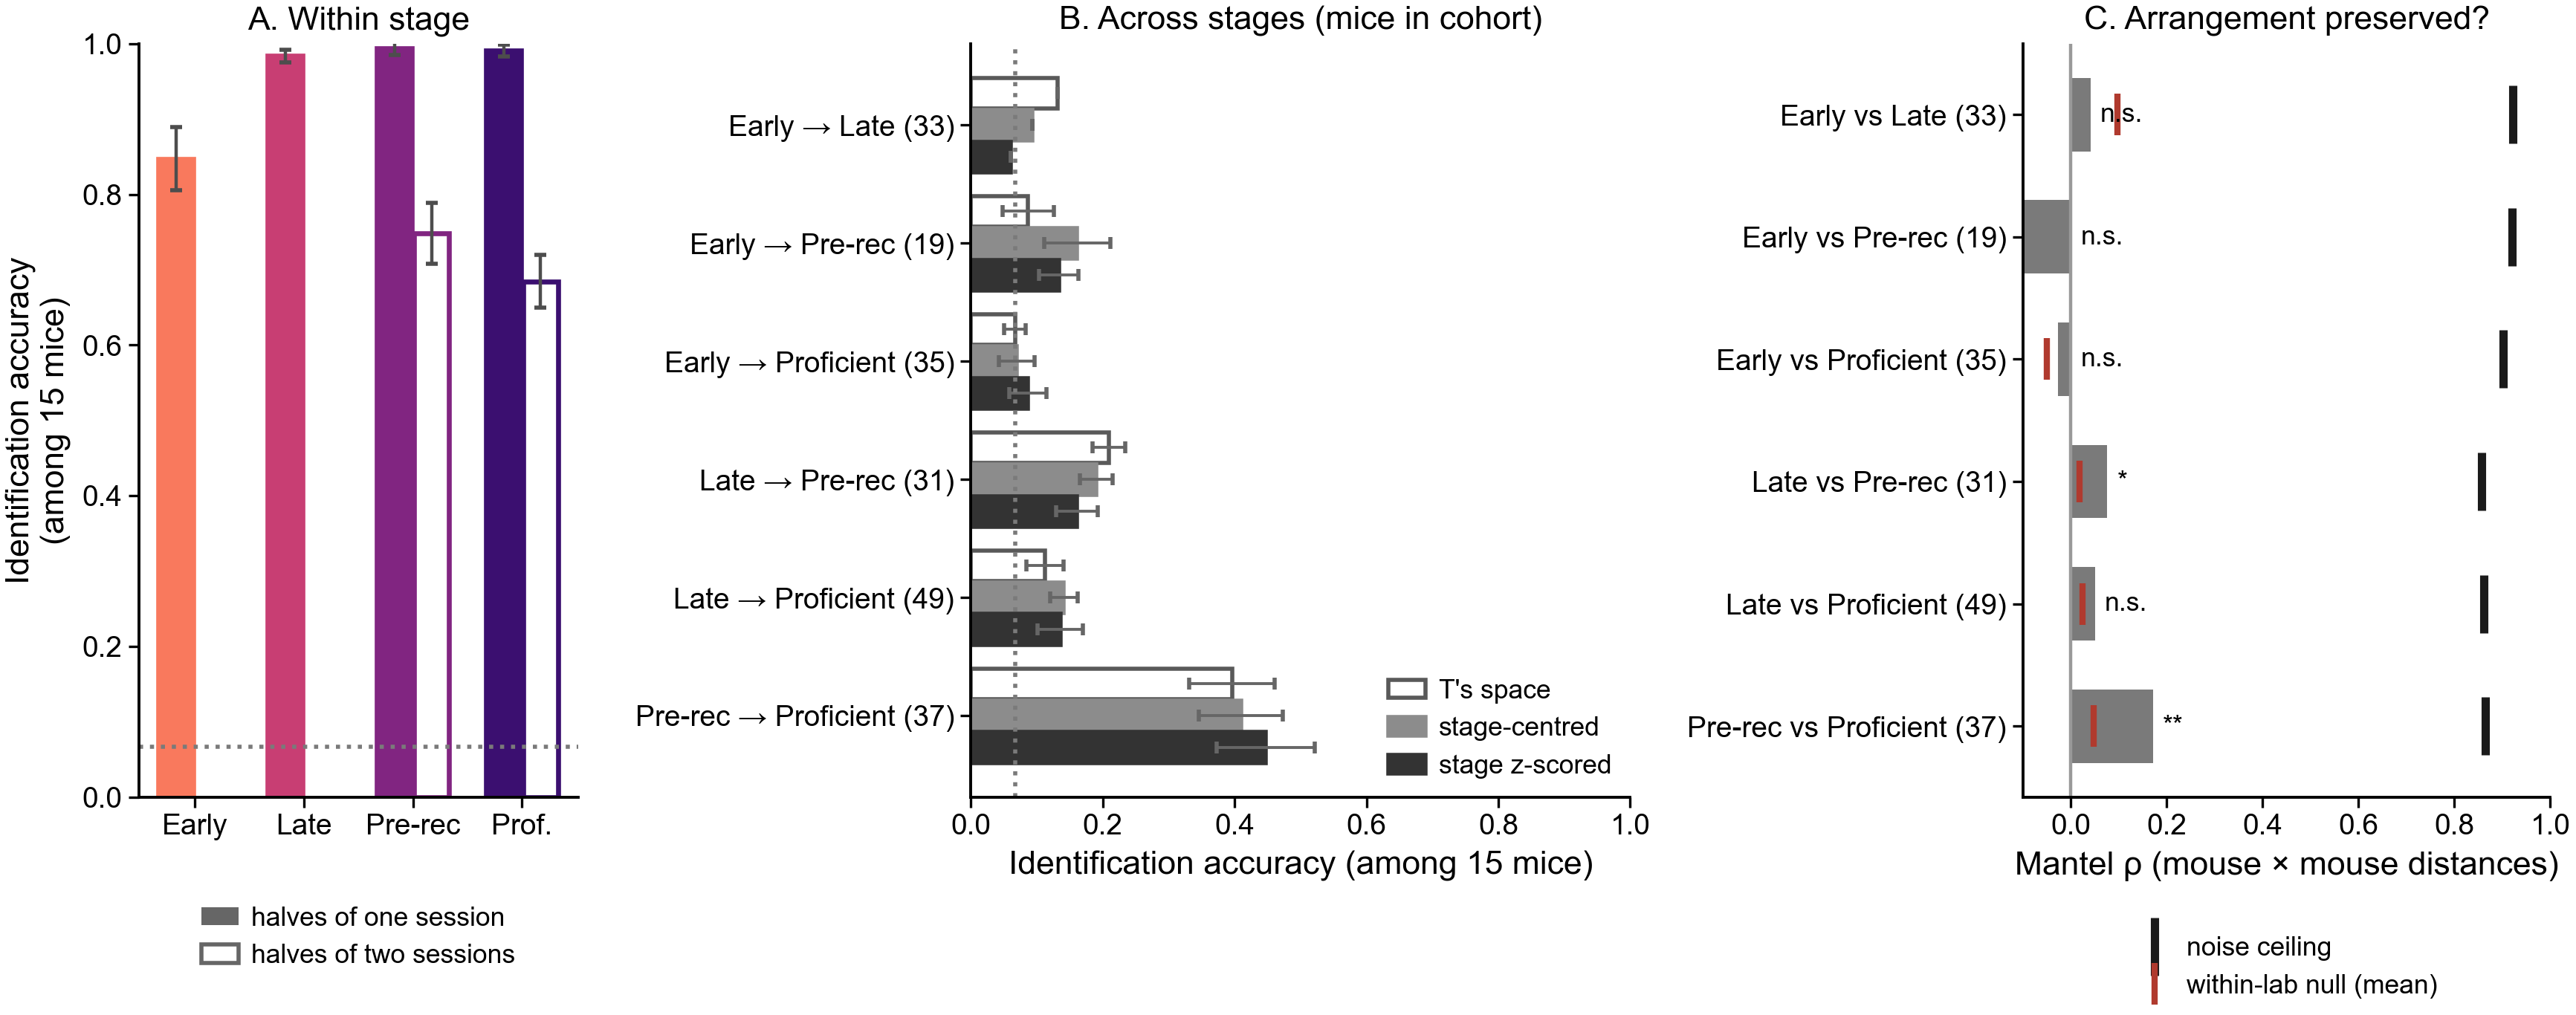

In [8]:
w, h = ps.SIZES[ps.MODE]['double']
fig, axs = plt.subplots(1, 3, figsize=(w * 1.25, h * 1.15),
                        gridspec_kw={'width_ratios': [1, 1.5, 1.2]})
fs_small = plt.rcParams['font.size'] * 0.8

# ---- A ----------------------------------------------------------------------------
ax = axs[0]
for i, s in enumerate(STAGES):
    for kind, dx, fc in (('within session', -0.17, STAGE_COLOR[s]),
                         ('across sessions', 0.17, 'white')):
        r = A_TAB[(A_TAB.stage == s) & (A_TAB.kind == kind)]
        if len(r):
            ax.bar(i + dx, r.top1_matched.iloc[0], width=0.32, color=fc,
                   edgecolor=STAGE_COLOR[s], lw=1.2, yerr=r.top1_sd.iloc[0],
                   error_kw=dict(lw=0.8, ecolor='0.3'))
ax.axhline(1 / N_MATCH, color=ps.NEUTRAL, ls=':', lw=1)
ax.set_xticks(range(len(STAGES)))
ax.set_xticklabels(['Early', 'Late', 'Pre-rec', 'Prof.'])
ax.set_ylim(0, 1)
ax.set_ylabel(f'Identification accuracy\n(among {N_MATCH} mice)')
ax.set_title('A. Within stage', fontsize=plt.rcParams['font.size'])
from matplotlib.patches import Patch
ax.legend(handles=[Patch(facecolor='0.4', label='halves of one session'),
                   Patch(facecolor='white', edgecolor='0.4', label='halves of two sessions')],
          frameon=False, fontsize=fs_small, loc='upper center', bbox_to_anchor=(0.5, -0.12))

# ---- B ----------------------------------------------------------------------------
ax = axs[1]
pairs = [f'{a} → {b}' for a, b in PAIRS]
mode_style = {"T's space": ('white', '0.35'), 'stage-centred': ('0.55', '0.55'),
              'stage z-scored': ('0.2', '0.2')}
for j, mode in enumerate(MODES):
    sub = B_TAB[B_TAB['mode'] == mode].set_index('pair').reindex(pairs)
    ax.barh(np.arange(len(pairs)) + (j - 1) * 0.27, sub.top1_matched, height=0.26,
            color=mode_style[mode][0], edgecolor=mode_style[mode][1], lw=1, label=mode,
            xerr=sub.top1_sd, error_kw=dict(lw=0.7, ecolor='0.4'))
ax.axvline(1 / N_MATCH, color=ps.NEUTRAL, ls=':', lw=1)
ax.set_yticks(range(len(pairs)))
ax.set_yticklabels([f'{p} ({n})' for p, n in
                    zip(pairs, B_TAB.groupby('pair', sort=False).n_mice.first().reindex(pairs))])
ax.invert_yaxis()
ax.set_xlim(0, 1)
ax.set_xlabel(f'Identification accuracy (among {N_MATCH} mice)')
ax.set_title('B. Across stages (mice in cohort)', fontsize=plt.rcParams['font.size'])
ax.legend(frameon=False, fontsize=fs_small, loc='lower right')

# ---- C ----------------------------------------------------------------------------
ax = axs[2]
yy = np.arange(len(C_TAB))
ax.barh(yy, C_TAB.mantel, height=0.6, color=ps.NEUTRAL)
ax.plot(C_TAB.ceiling, yy, '|', ms=14, mew=2, color='0.1', label='noise ceiling')
ax.plot(C_TAB.null_within_lab, yy, '|', ms=10, mew=1.5, color='#B03A2E',
        label='within-lab null (mean)')
for y_, (_, r) in zip(yy, C_TAB.iterrows()):
    ax.text(max(r.mantel, 0) + 0.02, y_, ps.stars(r.p_within_lab) if r.p_within_lab < 0.05
            else 'n.s.', va='center', fontsize=fs_small)
ax.axvline(0, color='0.6', lw=0.8)
ax.set_yticks(yy)
ax.set_yticklabels([f'{p} ({n})' for p, n in zip(C_TAB.pair, C_TAB.n_mice)])
ax.invert_yaxis()
ax.set_xlim(-0.1, 1)
ax.set_xlabel('Mantel ρ (mouse × mouse distances)')
ax.set_title('C. Arrangement preserved?', fontsize=plt.rcParams['font.size'])
ax.legend(frameon=False, fontsize=fs_small, loc='upper center', bbox_to_anchor=(0.5, -0.16))

fig.tight_layout()
ps.savefig(fig, 'individuality_across_learning', svg=True)
plt.show()

## D. A continuous score per dimension: does a mouse keep its place on each individuality axis?

Identifying a mouse is all-or-nothing and needs many dimensions to agree. Here each axis is
tested on its own: **is a mouse's position on axis k at stage S correlated, across mice, with
its position on axis k at Proficient?** A correlation ignores offsets and rescaling of the
axis, so the stage shift cannot affect it.

* **Axes:** the proficient individuality axes, from an equal-mouse-weight LDA (as in
  `lda_shrinkage`, shrinkage 0.5). It is fit on the proficient sessions of mice with
  ≥ 3 of them, in this notebook's `paw_wheel` syllable model.
* **Positions:** at stage S, one random session per mouse (Early and Late have only one);
  at Proficient, the mean over the mouse's sessions. Averaged over `N_SPLITS` draws.
* **ρ:** Spearman across mice, with a permutation p-value (free and within-lab) and a 95%
  bootstrap CI over mice.
* **Disattenuated ρ** = ρ / √(rel_S · rel_Prof): what the correlation would be with
  noise-free positions. rel_S is the within-session split-half reliability of the axis
  position (optimistic, which makes the correction conservative), and rel_Prof the
  split-by-session reliability of the proficient mean, both Spearman–Brown corrected.
* **MDE:** the smallest |ρ| detectable with 80% power at α = 0.05 for that cohort size. An
  observed ρ below it, with a CI that excludes large values, is a *bounded* null.
* **Lab-centred ρ:** positions minus their lab's mean at each stage, because LD1 is
  lab-confounded.

Independence: the axes are fit on proficient data only, so the stage-S projections are
independent of the fit and the permutation null is exact. Near-tied axes rotate (see the
stability supplement in `lda_shrinkage_figures`), so read LD2 onward as a group. The last
row is a **subspace** score that does not depend on the rotation: linear CKA between the
stage-S and Proficient positions in the top `K_SUBSPACE` axes, with its own permutation null.

In [9]:
from scipy import linalg
from scipy.stats import norm

K_AXES = 10
K_SUBSPACE = 10
N_BOOT = 1000


def fit_mouse_weighted(Xt, yt, shrinkage):
    """Equal-mouse-weight LDA, copied from 4_mice/lda_shrinkage -- keep in sync."""
    classes = np.unique(yt)
    M = np.stack([Xt[yt == c].mean(axis=0) for c in classes])
    grand = M.mean(axis=0)
    Sb = np.cov((M - grand).T, bias=True)
    R = Xt - M[np.searchsorted(classes, yt)]
    Sw = R.T @ R / (len(Xt) - len(classes))
    Sw = (1 - shrinkage) * Sw + shrinkage * np.trace(Sw) / len(Sw) * np.eye(len(Sw))
    evals, evecs = linalg.eigh(Sb, Sw)
    order = np.argsort(evals)[::-1][:len(classes) - 1]
    return evecs[:, order], grand


_pr = DATA_BY_STAGE['Proficient']
_n = pd.Series(_pr['sess_mouse']).value_counts()
_fit_sess = np.where(np.isin(_pr['sess_mouse'], _n[_n >= 3].index))[0]
_colmean = np.nanmean(_pr['full'], axis=0)


def fillna(A):
    A = np.array(A, float)
    bad = np.isnan(A)
    A[bad] = np.broadcast_to(_colmean, A.shape)[bad]
    return A


W_LD, G_LD = fit_mouse_weighted(fillna(_pr['full'][_fit_sess]), _pr['sess_mouse'][_fit_sess], 0.5)
W_LD = W_LD[:, :max(K_AXES, K_SUBSPACE)]
PROJ = lambda A: (fillna(A) - G_LD) @ W_LD
LD_MICE = np.unique(_pr['sess_mouse'][_fit_sess])
print(f'proficient individuality axes: {len(_fit_sess)} sessions, {len(LD_MICE)} mice')

# proficient position = mean over the mouse's sessions, and its split-by-session reliability
_Zp = PROJ(_pr['full'])
PROF_POS = pd.DataFrame(_Zp).groupby(_pr['sess_mouse']).mean()


def prof_reliability(mice, rng, n_rep=N_SPLITS):
    """Split each mouse's proficient sessions into two halves (mice with >= 2), correlate
    the half-means across mice per axis, Spearman-Brown corrected."""
    rs = []
    multi = [m for m in mice if (_pr['sess_mouse'] == m).sum() >= 2]
    for _ in range(n_rep):
        A, B = [], []
        for m in multi:
            idx = rng.permutation(np.where(_pr['sess_mouse'] == m)[0])
            h = len(idx) // 2
            A.append(_Zp[idx[:h]].mean(0)); B.append(_Zp[idx[h:]].mean(0))
        A, B = np.array(A), np.array(B)
        rs.append([spearmanr(A[:, k], B[:, k])[0] for k in range(W_LD.shape[1])])
    r = np.mean(rs, axis=0)
    return 2 * r / (1 + r)


def stage_positions(st, mice, rng, n_trials=None):
    """One random session per mouse at this stage, projected; optionally with the session
    mean computed from only `n_trials` random trials (the power analysis, E)."""
    idx = one_session_per_mouse(st, rng, mice)
    sess = np.array([idx[m] for m in mice])
    if n_trials is None:
        X = st['full'][sess]
    else:
        X = np.empty((len(sess), st['F'].shape[1]))
        for i, s_ in enumerate(sess):
            rows = np.where(st['sess_codes'] == s_)[0]
            pick = rng.choice(rows, min(n_trials, len(rows)), replace=False)
            X[i] = np.nanmean(st['F'][pick], axis=0)
    return PROJ(X)


def stage_reliability(st, mice, rng, n_rep=N_SPLITS):
    """Within-session split-half reliability of each axis position, across mice."""
    rs = []
    for _ in range(n_rep):
        idx = one_session_per_mouse(st, rng, mice)
        A, B = half_split(st, np.array([idx[m] for m in mice]), rng)
        PA, PB = PROJ(A), PROJ(B)
        rs.append([spearmanr(PA[:, k], PB[:, k])[0] for k in range(W_LD.shape[1])])
    r = np.mean(rs, axis=0)
    return 2 * r / (1 + r)


def lab_centre(P, labs):
    P = np.array(P, float)
    for l in np.unique(labs):
        P[labs == l] -= P[labs == l].mean(axis=0)
    return P


def mde(n, alpha=0.05, power=0.8):
    return float(np.tanh((norm.ppf(1 - alpha / 2) + norm.ppf(power)) / np.sqrt(n - 3)))


def axis_correlations(S, P, labs, rng, n_perm=N_PERM, n_boot=N_BOOT):
    """Per-axis Spearman between stage positions S and proficient positions P (mice x axes)."""
    n = len(S)
    rho = np.array([spearmanr(S[:, k], P[:, k])[0] for k in range(K_AXES)])
    groups = [np.where(labs == l)[0] for l in np.unique(labs)]
    nf, nl = np.empty((n_perm, K_AXES)), np.empty((n_perm, K_AXES))
    for i in range(n_perm):
        p = rng.permutation(n)
        q = np.arange(n)
        for g in groups:
            q[g] = rng.permutation(g)
        nf[i] = [spearmanr(S[p, k], P[:, k])[0] for k in range(K_AXES)]
        nl[i] = [spearmanr(S[q, k], P[:, k])[0] for k in range(K_AXES)]
    boot = np.empty((n_boot, K_AXES))
    for i in range(n_boot):
        b = rng.integers(0, n, n)
        boot[i] = [spearmanr(S[b, k], P[b, k])[0] for k in range(K_AXES)]
    # two-sided p: is |rho| larger than |null|
    p_free = (np.sum(np.abs(nf) >= np.abs(rho), axis=0) + 1) / (n_perm + 1)
    p_lab = (np.sum(np.abs(nl) >= np.abs(rho), axis=0) + 1) / (n_perm + 1)
    lo, hi = np.nanpercentile(boot, [2.5, 97.5], axis=0)
    return rho, p_free, p_lab, lo, hi


def cka_linear(X, Y):
    X = X - X.mean(0); Y = Y - Y.mean(0)
    return float(np.linalg.norm(X.T @ Y) ** 2 /
                 (np.linalg.norm(X.T @ X) * np.linalg.norm(Y.T @ Y)))


D_ROWS, D_SUB = [], []
for s in ['Early', 'Late', 'Pre-rec']:
    st = DATA_BY_STAGE[s]
    mice = sorted(set(st['sess_mouse']) & set(LD_MICE) & set(LAB_OF_MOUSE.index))
    labs = LAB_OF_MOUSE.reindex(mice).to_numpy()
    rng = np.random.default_rng([SEED, 21, STAGES.index(s)])
    # stage positions averaged over session draws (a no-op for one-session stages)
    S = np.mean([stage_positions(st, mice, rng) for _ in range(N_SPLITS)], axis=0)
    P = PROF_POS.loc[mice].to_numpy()
    rho, pf, pl, lo, hi = axis_correlations(S[:, :K_AXES], P[:, :K_AXES], labs, rng)
    rho_lab = np.array([spearmanr(lab_centre(S, labs)[:, k], lab_centre(P, labs)[:, k])[0]
                        for k in range(K_AXES)])
    rel_s = stage_reliability(st, mice, rng)[:K_AXES]
    rel_p = prof_reliability(mice, rng)[:K_AXES]
    dis = rho / np.sqrt(np.clip(rel_s, 1e-3, None) * np.clip(rel_p, 1e-3, None))
    for k in range(K_AXES):
        D_ROWS.append(dict(stage=s, axis=f'LD{k + 1}', n_mice=len(mice), rho=rho[k],
                           ci_lo=lo[k], ci_hi=hi[k], p_free=pf[k], p_within_lab=pl[k],
                           rho_lab_centred=rho_lab[k], rel_stage=rel_s[k], rel_prof=rel_p[k],
                           rho_disattenuated=dis[k], mde=mde(len(mice))))
    # rotation-free subspace score
    obs = cka_linear(S[:, :K_SUBSPACE], P[:, :K_SUBSPACE])
    null = np.array([cka_linear(S[rng.permutation(len(S)), :K_SUBSPACE], P[:, :K_SUBSPACE])
                     for _ in range(N_PERM)])
    D_SUB.append(dict(stage=s, n_mice=len(mice), cka=obs, null_mean=null.mean(),
                      p=(np.sum(null >= obs) + 1) / (N_PERM + 1)))
D_TAB = pd.DataFrame(D_ROWS)
D_SUB = pd.DataFrame(D_SUB)
pd.set_option('display.max_rows', 60)
print(f'top-{K_SUBSPACE} subspace (linear CKA, stage vs Proficient positions):')
print(D_SUB.round(3).to_string(index=False))
D_TAB.round(3)

proficient individuality axes: 269 sessions, 58 mice


top-10 subspace (linear CKA, stage vs Proficient positions):
  stage  n_mice   cka  null_mean     p
  Early      35 0.228      0.197 0.175
   Late      49 0.245      0.154 0.001
Pre-rec      37 0.581      0.167 0.000


,stage,axis,n_mice,rho,ci_lo,ci_hi,p_free,p_within_lab,rho_lab_centred,rel_stage,rel_prof,rho_disattenuated,mde
0,Early,LD1,35,0.303,-0.077,0.618,0.083,0.121,0.271,0.902,0.963,0.325,0.458
1,Early,LD2,35,0.107,-0.226,0.415,0.537,0.415,0.176,0.827,0.981,0.119,0.458
2,Early,LD3,35,0.156,-0.191,0.485,0.373,0.773,-0.135,0.894,0.971,0.168,0.458
3,Early,LD4,35,0.162,-0.184,0.478,0.354,0.240,0.058,0.892,0.962,0.175,0.458
4,Early,LD5,35,-0.329,-0.612,0.029,0.049,0.294,-0.082,0.822,0.907,-0.381,0.458
5,Early,LD6,35,0.303,-0.099,0.644,0.079,0.038,0.406,0.901,0.956,0.327,0.458
6,Early,LD7,35,-0.009,-0.377,0.358,0.958,0.951,0.021,0.811,0.919,-0.011,0.458
7,Early,LD8,35,0.153,-0.212,0.492,0.373,0.400,0.295,0.705,0.944,0.187,0.458
8,Early,LD9,35,0.244,-0.099,0.529,0.150,0.084,0.299,0.853,0.924,0.274,0.458
9,Early,LD10,35,0.166,-0.148,0.457,0.331,0.288,0.335,0.881,0.925,0.183,0.458


## E. Is it statistical power? A positive control degraded to Early's conditions

Pre-recording → Proficient is the pair where persistence *is* detected. Early → Proficient
differs from it in what costs power:

* **trials per session:** Early sessions are much shorter, so each session vector is noisier;
* **mice:** 35 in the Early cohort here (19 when Pre-recording is also required);
* one session per mouse (already matched: every test above uses one session at stage S).

Here Pre-recording → Proficient is re-run with each Pre-recording session's mean built from
only **T random trials**, sweeping T through Early's median, at the full cohort and at 19
mice. Proficient keeps its full sessions, exactly as in Early → Proficient. Scores: B
(identification among `N_MATCH`, stage z-scored), C (Mantel), and D (mean ρ over LD1–5).
The Early → Proficient result is drawn at Early's trial count.

* **If the degraded positive control stays well above chance at Early's T,** Early's failure
  is not power: Early really does not carry over.
* **If it collapses to Early's level,** the data cannot tell, and Early's null is
  uninformative.

In [10]:
_early_T = int(np.median(pd.Series(DATA_BY_STAGE['Early']['sess_codes']).value_counts()))
_pre_T = int(np.median(pd.Series(DATA_BY_STAGE['Pre-rec']['sess_codes']).value_counts()))
T_GRID = sorted(set([25, 50, 100, _early_T, 400, _pre_T]))
print(f'median trials per session: Early {_early_T}, Pre-rec {_pre_T}')

_sa, _sb = DATA_BY_STAGE['Pre-rec'], DATA_BY_STAGE['Proficient']
_cohort_full = sorted(set(_sa['sess_mouse']) & set(_sb['sess_mouse']) & set(LD_MICE))
(_ma, _va), (_mb, _vb) = STATS['Pre-rec'], STATS['Proficient']
_f_z = space(np.vstack([(_sa['full'] - _ma) / _va, (_sb['full'] - _mb) / _vb]))
_f_b = space(_sb['full'])


def degraded(n_mice, T, rng):
    mice = sorted(rng.choice(_cohort_full, min(n_mice, len(_cohort_full)), replace=False))
    # query side: one Pre-rec session per mouse from T trials; candidate: one full Prof session
    idx_a = one_session_per_mouse(_sa, rng, mice)
    Xa = np.empty((len(mice), _sa['F'].shape[1]))
    for i, m in enumerate(mice):
        rows = np.where(_sa['sess_codes'] == idx_a[m])[0]
        Xa[i] = np.nanmean(_sa['F'][rng.choice(rows, min(T, len(rows)), replace=False)], axis=0)
    idx_b = one_session_per_mouse(_sb, rng, mice)
    Xb = _sb['full'][[idx_b[m] for m in mice]]
    # B: identification, stage z-scored
    top1 = rank_scores(sqdist(_f_z((Xa - _ma) / _va), _f_z((Xb - _mb) / _vb)),
                       np.arange(len(mice)))[0]
    # C: Mantel between the two stages' own spaces
    mant = spearmanr(rdm_upper(space(_sa['full'])(Xa)), rdm_upper(_f_b(Xb)))[0]
    # D: mean rho over LD1-5, stage position vs proficient mean position
    Pa, Pp = PROJ(Xa), PROF_POS.loc[mice].to_numpy()
    rho = np.mean([spearmanr(Pa[:, k], Pp[:, k])[0] for k in range(5)])
    return top1, mant, rho


E_ROWS = []
for n_m in (len(_cohort_full), 19):
    for T in T_GRID:
        rng = np.random.default_rng([SEED, 31, n_m, T])
        r = np.array([degraded(n_m, T, rng) for _ in range(N_SPLITS)])
        E_ROWS.append(dict(n_mice=n_m, trials=T, top1=r[:, 0].mean(), top1_sd=r[:, 0].std(),
                           mantel=r[:, 1].mean(), mantel_sd=r[:, 1].std(),
                           rho_ld15=r[:, 2].mean(), rho_sd=r[:, 2].std()))
E_TAB = pd.DataFrame(E_ROWS)

# the Early -> Proficient values on the same three scores, for the overlay
_e = B_TAB[(B_TAB.pair == 'Early → Proficient') & (B_TAB['mode'] == 'stage z-scored')]
EARLY_REF = dict(top1=float(_e.top1_matched.iloc[0]),
                 mantel=float(C_TAB.loc[C_TAB.pair == 'Early vs Proficient', 'mantel'].iloc[0]),
                 rho_ld15=float(D_TAB[(D_TAB.stage == 'Early')
                                      & D_TAB.axis.isin([f'LD{k}' for k in range(1, 6)])]
                                .rho.mean()))
print('Early -> Proficient on the same scores:', {k: round(v, 3) for k, v in EARLY_REF.items()})
E_TAB.round(3)

median trials per session: Early 203, Pre-rec 728


Early -> Proficient on the same scores: {'top1': 0.086, 'mantel': -0.027, 'rho_ld15': 0.08}


,n_mice,trials,top1,top1_sd,mantel,mantel_sd,rho_ld15,rho_sd
0,37,25,0.281,0.049,0.044,0.091,0.637,0.030
1,37,50,0.313,0.068,0.047,0.168,0.663,0.030
2,37,100,0.363,0.050,0.090,0.122,0.692,0.028
3,37,203,0.393,0.067,0.133,0.151,0.690,0.027
4,37,400,0.401,0.062,0.184,0.108,0.697,0.032
5,37,728,0.426,0.063,0.130,0.126,0.708,0.022
6,19,25,0.316,0.086,-0.010,0.190,0.641,0.062
7,19,50,0.336,0.095,0.054,0.140,0.667,0.065
8,19,100,0.349,0.085,0.049,0.163,0.688,0.035
9,19,203,0.405,0.106,0.080,0.191,0.691,0.035


not saved (ps.SAVE_FIGURES is False): figures/individuality_across_learning_power_02-10-2026.png, figures/individuality_across_learning_power_02-10-2026.svg   -- ps.saving(True) to write, or pass save=True


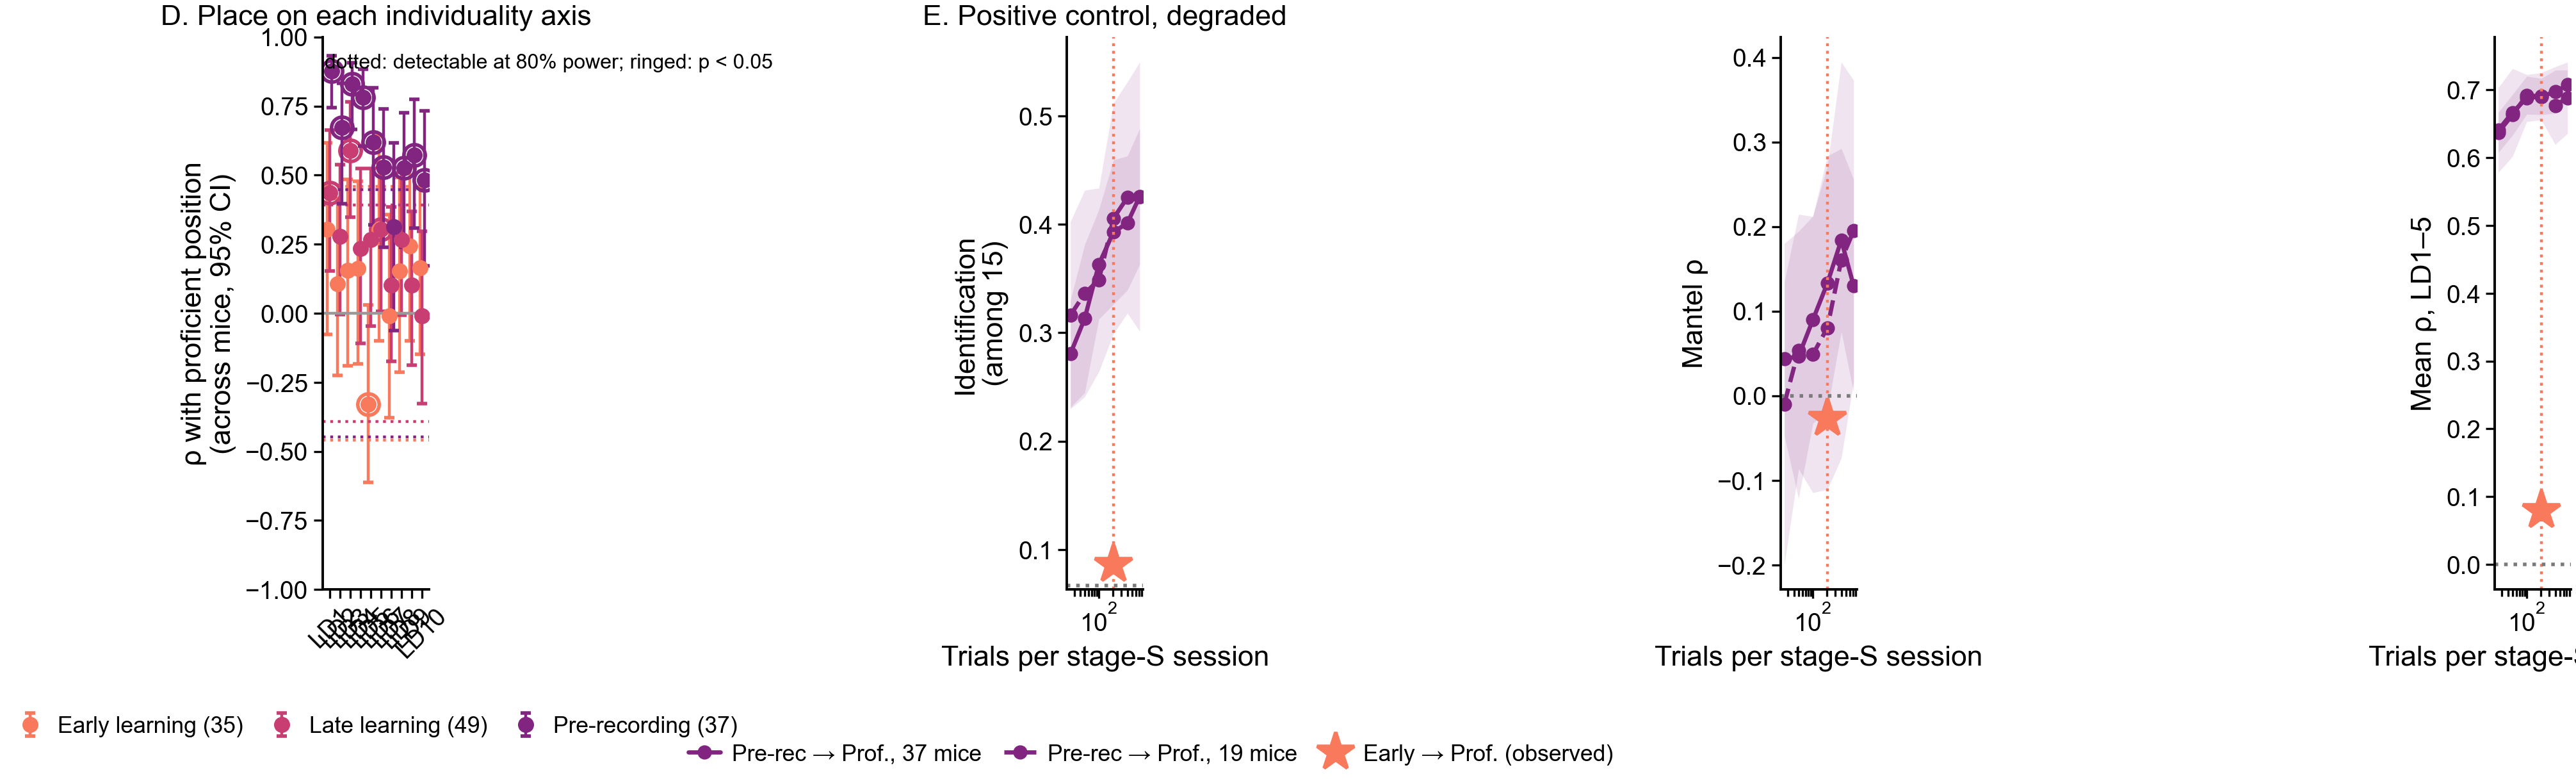

In [11]:
w, h = ps.SIZES[ps.MODE]['double']
fig, axs = plt.subplots(1, 4, figsize=(w * 1.35, h * 1.05),
                        gridspec_kw={'width_ratios': [1.4, 1, 1, 1]})
fs_small = plt.rcParams['font.size'] * 0.8

# ---- D: per-axis rho, each stage vs Proficient -------------------------------------
ax = axs[0]
kk = np.arange(1, K_AXES + 1)
for j, s in enumerate(['Early', 'Late', 'Pre-rec']):
    d = D_TAB[D_TAB.stage == s]
    x = kk + (j - 1) * 0.22
    ax.errorbar(x, d.rho, yerr=[d.rho - d.ci_lo, d.ci_hi - d.rho], fmt='o', ms=3.5,
                color=STAGE_COLOR[s], elinewidth=0.8, label=f'{STAGE_LABEL[s]} ({d.n_mice.iloc[0]})')
    sig = d.p_free.to_numpy() < 0.05
    ax.plot(x[sig], d.rho.to_numpy()[sig], 'o', ms=6, mfc='none', mec=STAGE_COLOR[s], mew=1)
    ax.axhline(d.mde.iloc[0], color=STAGE_COLOR[s], ls=':', lw=0.8)
    ax.axhline(-d.mde.iloc[0], color=STAGE_COLOR[s], ls=':', lw=0.8)
ax.axhline(0, color='0.6', lw=0.8)
ax.set_xticks(kk)
ax.set_xticklabels([f'LD{k}' for k in kk], rotation=45)
ax.set_ylim(-1, 1)
ax.set_ylabel('ρ with proficient position\n(across mice, 95% CI)')
ax.set_title('D. Place on each individuality axis', fontsize=plt.rcParams['font.size'])
ax.legend(frameon=False, fontsize=fs_small, loc='upper center', bbox_to_anchor=(0.5, -0.2),
          ncol=3)
ax.text(0.02, 0.97, 'dotted: detectable at 80% power; ringed: p < 0.05',
        transform=ax.transAxes, fontsize=fs_small * 0.9, va='top')

# ---- E: degraded positive control --------------------------------------------------
for ax, key, lbl, chance in ((axs[1], 'top1', f'Identification\n(among {N_MATCH})', 1 / N_MATCH),
                             (axs[2], 'mantel', 'Mantel ρ', 0),
                             (axs[3], 'rho_ld15', 'Mean ρ, LD1–5', 0)):
    for n_m, ls in ((len(_cohort_full), '-'), (19, '--')):
        e = E_TAB[E_TAB.n_mice == n_m]
        ax.plot(e.trials, e[key], ls=ls, marker='o', ms=3, color=STAGE_COLOR['Pre-rec'],
                label=f'Pre-rec → Prof., {n_m} mice')
        sd = e[{'top1': 'top1_sd', 'mantel': 'mantel_sd', 'rho_ld15': 'rho_sd'}[key]]
        ax.fill_between(e.trials, e[key] - sd, e[key] + sd, color=STAGE_COLOR['Pre-rec'],
                        alpha=0.12, lw=0)
    ax.plot(_early_T, EARLY_REF[key], '*', ms=11, color=STAGE_COLOR['Early'],
            label='Early → Prof. (observed)', zorder=5)
    ax.axvline(_early_T, color=STAGE_COLOR['Early'], ls=':', lw=0.8)
    ax.axhline(chance, color=ps.NEUTRAL, ls=':', lw=1)
    ax.set_xscale('log')
    ax.set_xlabel('Trials per stage-S session')
    ax.set_ylabel(lbl)
axs[1].set_title('E. Positive control, degraded', fontsize=plt.rcParams['font.size'])
axs[1].legend(frameon=False, fontsize=fs_small, loc='upper center', bbox_to_anchor=(1.1, -0.25),
              ncol=3)
fig.tight_layout()
ps.savefig(fig, 'individuality_across_learning_power', svg=True)
plt.show()

## F. Which features carry over?

The same cross-stage questions, asked with different session descriptions. Each one is
built from the same session means:

| feature set | n | idea |
|---|---|---|
| all | 360 | syllable probability per time bin (everything above) |
| paw | 280 | paw states only |
| whisk | 40 | whisking only: arguably less dependent on paw tracking and camera angle |
| lick | 40 | licking only |
| per epoch | 36 | each syllable's mean probability within each of the 4 epochs, time bins collapsed |
| whole trial | 9 | each syllable's mean probability over the whole trial |

Collapsing time matters because Early trials unfold differently (long, variable reaction
times). A time-binned profile mixes *how the trial unfolds at this stage* with *what kind of
mouse this is*, and overall usage may be more stable.

For each set: the proficient LDA axes are refit in that feature space; **B** is cross-stage
identification among `N_MATCH` (stage z-scored), **D** is the mean ρ over LD1–5 (or as many
axes as the set allows) plus top-k CKA, and the **reference** is how identifiable proficient
mice are across two of their own sessions in that same space. A feature set can only carry
over what it captures at proficiency.

In [12]:
PER_BIN = (N_PAW_STATES - 1) + 2          # 7 paw + whisk + lick per time bin
N_BINS = DATA_BY_STAGE['Proficient']['full'].shape[1] // PER_BIN


def feature_set(X, kind):
    X = np.asarray(X, float)
    B = X.reshape(len(X), N_BINS, PER_BIN)
    with warnings.catch_warnings():
        warnings.simplefilter('ignore', RuntimeWarning)
        if kind == 'all':
            return X
        if kind == 'paw':
            return B[:, :, :PER_BIN - 2].reshape(len(X), -1)
        if kind == 'whisk':
            return B[:, :, PER_BIN - 2]
        if kind == 'lick':
            return B[:, :, PER_BIN - 1]
        if kind == 'per epoch':
            return np.nanmean(B.reshape(len(X), len(EPOCHS), -1, PER_BIN), axis=2) \
                     .reshape(len(X), -1)
        if kind == 'whole trial':
            return np.nanmean(B, axis=1)
    raise ValueError(kind)


FEATURE_SETS = ['all', 'paw', 'whisk', 'lick', 'per epoch', 'whole trial']


def fs_analysis(kind, rng):
    full = {s: feature_set(DATA_BY_STAGE[s]['full'], kind) for s in STAGES}
    pr = DATA_BY_STAGE['Proficient']
    col_mean = np.nanmean(full['Proficient'], axis=0)
    fill = lambda A: np.where(np.isnan(A), col_mean, A)
    keep = np.nanstd(full['Proficient'], axis=0) > 1e-8
    Wf, Gf = fit_mouse_weighted(fill(full['Proficient'][_fit_sess])[:, keep],
                                pr['sess_mouse'][_fit_sess], 0.5)
    n_ax = min(5, Wf.shape[1])
    n_sub = min(K_SUBSPACE, Wf.shape[1])
    proj = lambda A: (fill(A)[:, keep] - Gf) @ Wf
    prof_pos = pd.DataFrame(proj(full['Proficient'])).groupby(pr['sess_mouse']).mean()
    stats = {s: (np.nanmean(full[s], axis=0), np.nanstd(full[s], axis=0) + 1e-8)
             for s in STAGES}
    zs = lambda A, s: (A - stats[s][0]) / stats[s][1]
    rows = []

    # reference: proficient across-session identification in this space
    multi = [m for m in np.unique(pr['sess_mouse']) if (pr['sess_mouse'] == m).sum() >= 2]
    f_p = space(full['Proficient'])
    ref = []
    for _ in range(N_SPLITS):
        i1 = one_session_per_mouse(pr, rng, multi)
        i2 = one_session_per_mouse(pr, rng, multi, exclude={m: [i1[m]] for m in multi})
        Q = f_p(full['Proficient'][[i1[m] for m in multi]])
        C = f_p(full['Proficient'][[i2[m] for m in multi]])
        ref.append(rank_scores(sqdist(Q, C), np.arange(len(multi)))[0])

    for s in ['Early', 'Late', 'Pre-rec']:
        st = DATA_BY_STAGE[s]
        # B: identification, stage z-scored, cohort = mice at both stages
        cohort = sorted(set(st['sess_mouse']) & set(pr['sess_mouse']))
        f_ab = space(np.vstack([zs(full[s], s), zs(full['Proficient'], 'Proficient')]))
        top = []
        for _ in range(N_SPLITS):
            ia = one_session_per_mouse(st, rng, cohort)
            ib = one_session_per_mouse(pr, rng, cohort)
            Q = f_ab(zs(full[s][[ia[m] for m in cohort]], s))
            C = f_ab(zs(full['Proficient'][[ib[m] for m in cohort]], 'Proficient'))
            top.append(rank_scores(sqdist(Q, C), np.arange(len(cohort)))[0])
        # D: per-axis rho and subspace CKA vs proficient mean position
        mice = sorted(set(st['sess_mouse']) & set(LD_MICE))
        Sp = np.mean([proj(full[s][[one_session_per_mouse(st, rng, mice)[m] for m in mice]])
                      for _ in range(N_SPLITS)], axis=0)
        Pp = prof_pos.loc[mice].to_numpy()
        rho = np.array([spearmanr(Sp[:, k], Pp[:, k])[0] for k in range(n_ax)])
        null = np.array([[spearmanr(Sp[rng.permutation(len(Sp)), k], Pp[:, k])[0]
                          for k in range(n_ax)] for _ in range(N_PERM // 10)]).mean(axis=1)
        ck = cka_linear(Sp[:, :n_sub], Pp[:, :n_sub])
        ck_null = np.array([cka_linear(Sp[rng.permutation(len(Sp)), :n_sub], Pp[:, :n_sub])
                            for _ in range(N_PERM // 10)])
        rows.append(dict(features=kind, n_features=int(keep.sum()), stage=s,
                         ident=np.mean(top), ident_sd=np.std(top), n_ident=len(cohort),
                         ref_prof=np.mean(ref), rho_mean=rho.mean(), n_axes=n_ax,
                         p_rho_mean=(np.sum(null >= rho.mean()) + 1) / (len(null) + 1),
                         cka=ck, cka_null=ck_null.mean(),
                         p_cka=(np.sum(ck_null >= ck) + 1) / (len(ck_null) + 1)))
    return rows


F_TAB = pd.DataFrame([r for i, kind in enumerate(FEATURE_SETS)
                      for r in fs_analysis(kind, np.random.default_rng([SEED, 41, i]))])
F_TAB.round(3)

,features,n_features,stage,ident,ident_sd,n_ident,ref_prof,rho_mean,n_axes,p_rho_mean,cka,cka_null,p_cka
0,all,358,Early,0.087,0.028,35,0.676,0.080,5,0.164,0.228,0.197,0.182
1,all,358,Late,0.151,0.019,49,0.676,0.360,5,0.002,0.245,0.152,0.002
2,all,358,Pre-rec,0.449,0.052,37,0.676,0.748,5,0.002,0.570,0.168,0.002
3,paw,278,Early,0.061,0.021,35,0.572,0.064,5,0.190,0.149,0.179,0.804
4,paw,278,Late,0.120,0.029,49,0.572,0.315,5,0.002,0.206,0.154,0.034
5,paw,278,Pre-rec,0.383,0.080,37,0.572,0.730,5,0.002,0.612,0.174,0.002
6,whisk,40,Early,0.155,0.032,35,0.581,0.247,5,0.002,0.200,0.118,0.020
7,whisk,40,Late,0.217,0.033,49,0.581,0.320,5,0.002,0.182,0.100,0.008
8,whisk,40,Pre-rec,0.320,0.049,37,0.581,0.614,5,0.002,0.579,0.119,0.002
9,lick,40,Early,0.061,0.025,35,0.540,0.158,5,0.028,0.125,0.103,0.212


not saved (ps.SAVE_FIGURES is False): figures/individuality_across_learning_features_02-10-2026.png, figures/individuality_across_learning_features_02-10-2026.svg   -- ps.saving(True) to write, or pass save=True


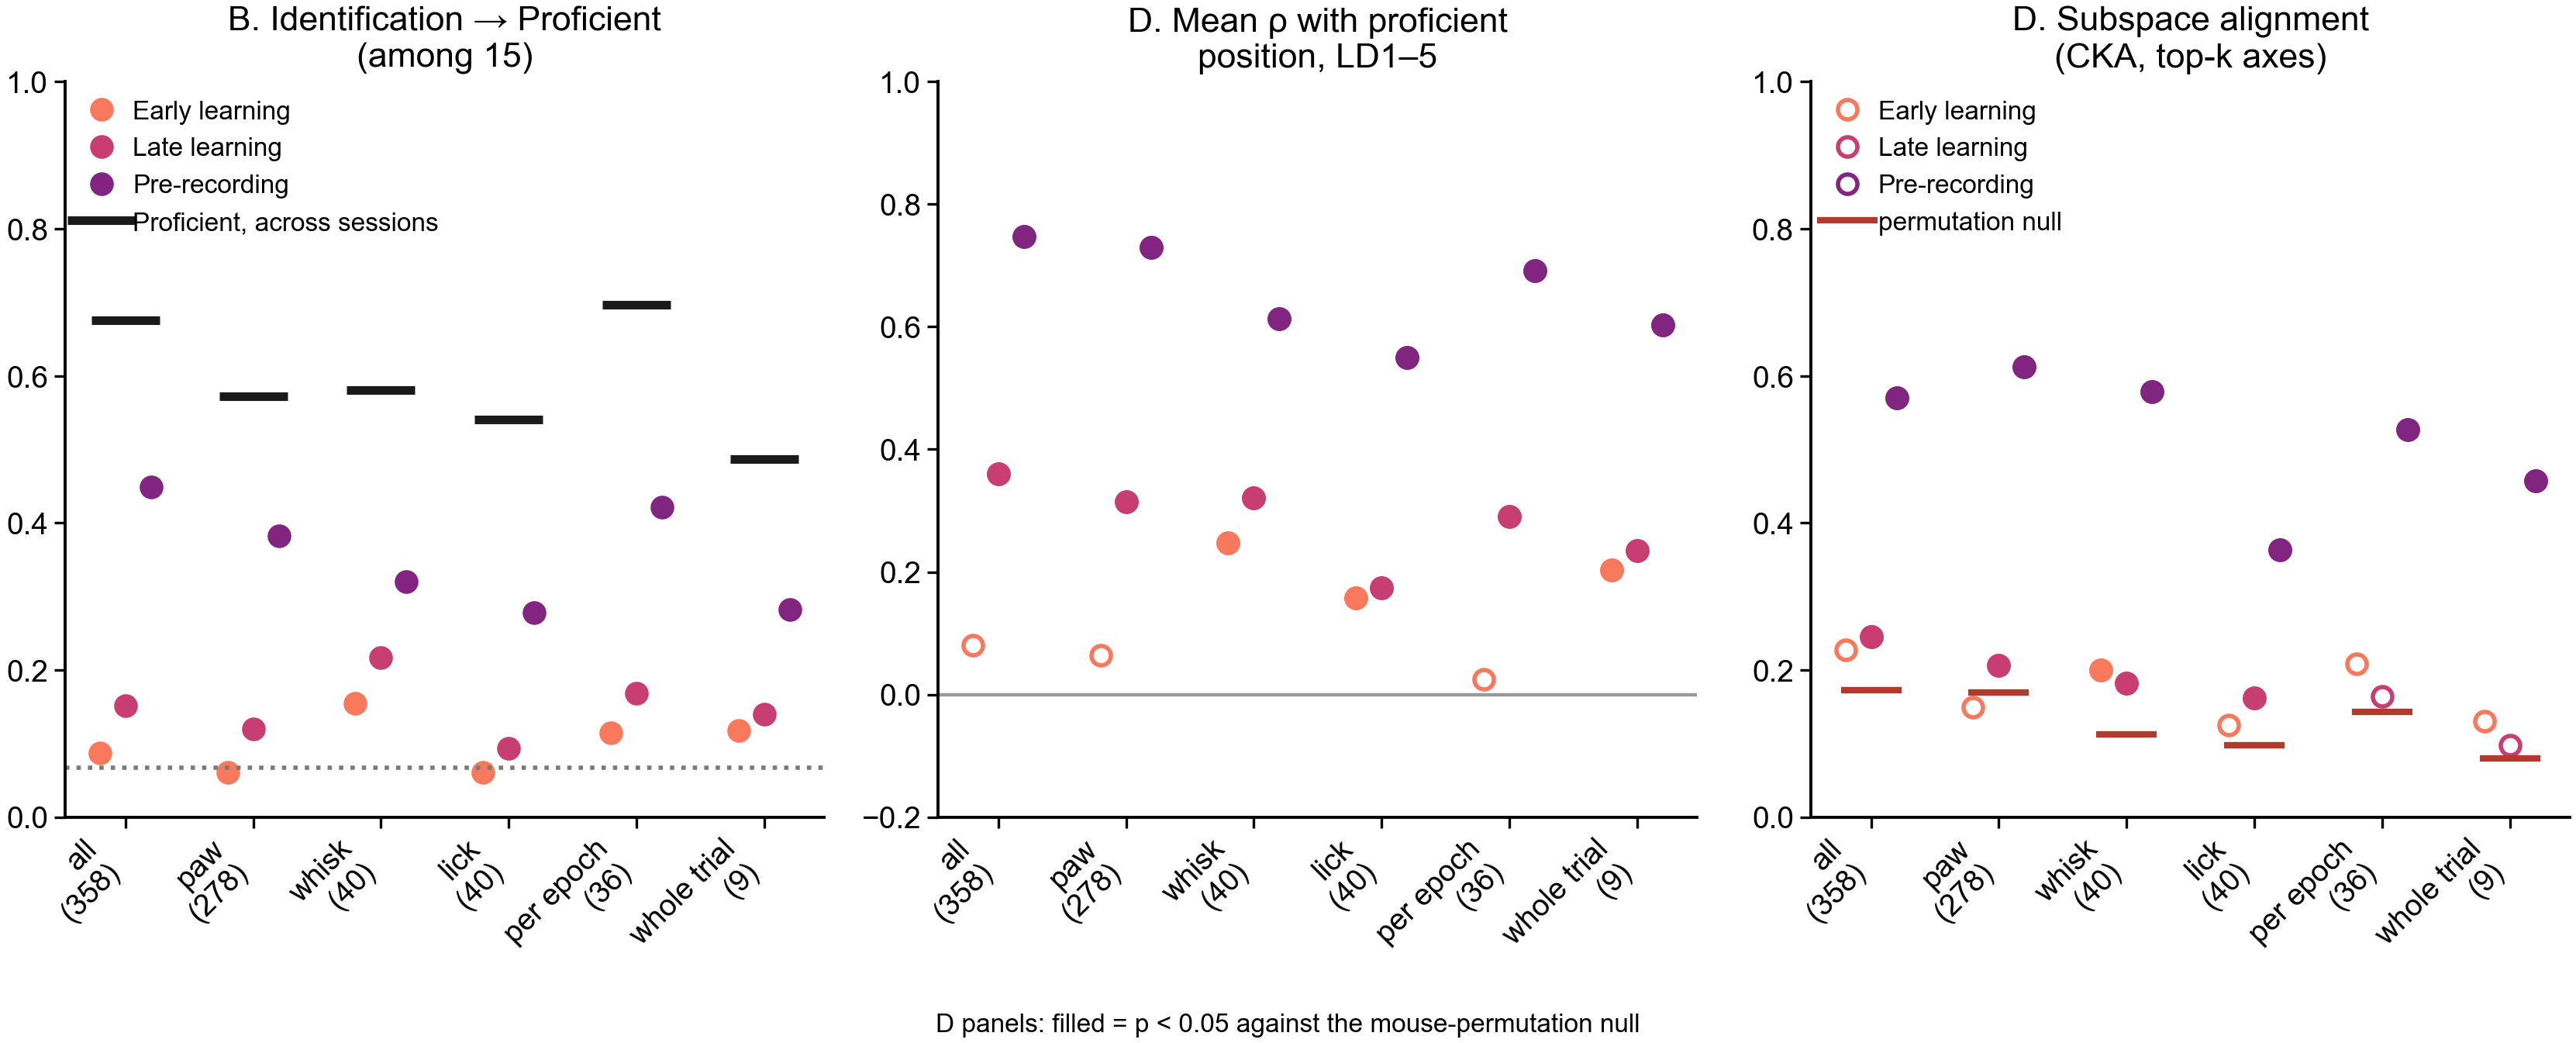

In [13]:
w, h = ps.SIZES[ps.MODE]['double']
fig, axs = plt.subplots(1, 3, figsize=(w * 1.2, h * 1.05), sharex=True)
xx = np.arange(len(FEATURE_SETS))
for ax, key, lbl in ((axs[0], 'ident', f'B. Identification → Proficient\n(among {N_MATCH})'),
                     (axs[1], 'rho_mean', 'D. Mean ρ with proficient\nposition, LD1–5'),
                     (axs[2], 'cka', 'D. Subspace alignment\n(CKA, top-k axes)')):
    for j, s in enumerate(['Early', 'Late', 'Pre-rec']):
        d = F_TAB[F_TAB.stage == s].set_index('features').reindex(FEATURE_SETS)
        p = d['p_rho_mean' if key == 'rho_mean' else 'p_cka'] if key != 'ident' else None
        x = xx + (j - 1) * 0.2
        ax.plot(x, d[key], 'o', ms=4.5, color=STAGE_COLOR[s], label=STAGE_LABEL[s],
                mfc=STAGE_COLOR[s] if p is None else 'none')
        if p is not None:                      # filled = p < 0.05 against its permutation null
            sig = p.to_numpy() < 0.05
            ax.plot(x[sig], d[key].to_numpy()[sig], 'o', ms=4.5, color=STAGE_COLOR[s])
    if key == 'ident':
        ref = F_TAB.groupby('features').ref_prof.first().reindex(FEATURE_SETS)
        ax.plot(xx, ref, '_', ms=16, mew=2, color='0.1', label='Proficient, across sessions')
        ax.axhline(1 / N_MATCH, color=ps.NEUTRAL, ls=':', lw=1)
    if key == 'cka':
        null = F_TAB.groupby('features').cka_null.mean().reindex(FEATURE_SETS)
        ax.plot(xx, null, '_', ms=14, mew=1.5, color='#B03A2E', label='permutation null')
    else:
        ax.axhline(0, color='0.6', lw=0.8) if key == 'rho_mean' else None
    ax.set_xticks(xx)
    ax.set_xticklabels([f'{k}\n({F_TAB.loc[F_TAB.features == k, "n_features"].iloc[0]})'
                        for k in FEATURE_SETS], rotation=45, ha='right')
    ax.set_title(lbl, fontsize=plt.rcParams['font.size'])
    ax.set_ylim(-0.2 if key == 'rho_mean' else 0, 1)
axs[0].legend(frameon=False, fontsize=plt.rcParams['font.size'] * 0.75, loc='upper left')
axs[2].legend(frameon=False, fontsize=plt.rcParams['font.size'] * 0.75, loc='upper left')
fig.text(0.5, -0.02, 'D panels: filled = p < 0.05 against the mouse-permutation null',
         ha='center', fontsize=plt.rcParams['font.size'] * 0.75)
fig.tight_layout()
ps.savefig(fig, 'individuality_across_learning_features', svg=True)
plt.show()

## Reading it

* **A low, B low:** there is no stable signature within a stage, so nothing can carry across.
* **A high, B low with every normalisation, C low:** mice are individual at each stage, but
  the signature changes with learning.
* **A high, B low in T's space but higher once centred:** the signature persists and the
  original test failed on the shift between stages.
* **D:** an axis whose ρ with Proficient is positive at Early, or whose CI excludes values
  above its MDE, says which individuality axes are already present early, or which are
  ruled out. That is finer than any whole-space test.
* **E:** if the degraded positive control stays above chance at Early's trial count, the
  Early null is a real absence of carry-over and not a lack of power.
* **C above its within-lab null but B low:** the *arrangement* of mice persists (similar mice
  stay similar) even though no single mouse is reliably re-identified. That is weaker
  preservation, the kind expected when within-stage noise is high.

**What this design still cannot do.**
- Early and Late have one session per mouse, so their within-stage score is the optimistic
  within-session one, and every cross-stage comparison involving them carries single-session
  noise. More sessions, not more mice, would fix it.
- Rig and camera change with stage for most mice, so a "shift" removed by centring is
  part behaviour and part setup. Centring cannot say which.
- Lab is nested in mouse. The within-lab null controls for labs staying labs, but a lab
  effect that *changes* across stages still looks like changed individuality.